In [26]:
import tqdm
import matplotlib.pyplot as plt

In [27]:
import numpy as np

def init_julia():
    """Initialize julia binary, turning off compiled modules if needed."""
    from julia.core import JuliaInfo, UnsupportedPythonError


    try:
        info = JuliaInfo.load(julia="julia")
    except FileNotFoundError:
        env_path = os.environ["PATH"]
        raise FileNotFoundError(
            f"Julia is not installed in your PATH. Please install Julia and add it to your PATH.\n\nCurrent PATH: {env_path}",
        )


    if not info.is_pycall_built():
        raise ImportError(import_error_string())


    Main = None
    try:
        from julia import Main as _Main


        Main = _Main
    except UnsupportedPythonError:
        # Static python binary, so we turn off pre-compiled modules.
        from julia.core import Julia


        jl = Julia(compiled_modules=False)
        from julia import Main as _Main


        Main = _Main


    return Main

Main = init_julia()

# Load required Julia packages into the Main namespace
Main.eval('using NLsolve')
Main.eval('using ForwardDiff')

def nsolve(func, initial_guess, method='trust_region', tol=1e-8, max_iter=1000):
    """
    Wrapper for Julia's NLsolve.nsolve to solve a system of nonlinear equations.
    
    Args:
        func: Python function representing the system f(x) = 0
        initial_guess: Initial guess as a numpy array or list
        method: Solver method ('trust_region', 'newton', etc.)
        tol: Tolerance for convergence
        max_iter: Maximum number of iterations
    
    Returns:
        Numpy array with the solution
    """
    # Convert initial guess to numpy array if it isn't already
    x0 = np.asarray(initial_guess, dtype=float)
    
    # Ensure PyCall is loaded in Julia
    Main.eval('using PyCall')
    
    # Pass the Python function to Julia
    Main.py_func = func
    
    # Define the Julia function
    func_str = """
    function jl_func(x)
        return Main.py_func(x)
    end
    """
    Main.eval(func_str)  # Define the Julia function
    
    # Convert x0 to a plain Python list of floats for Julia compatibility
    x0_list = x0.tolist()
    
    # Prepare the solver call based on the method
    method_sym = f":{method}" if method else ":trust_region"  # Default to trust_region
    jl_cmd = f"""
    result = NLsolve.nlsolve(jl_func, {x0_list}, method={method_sym}, ftol={tol}, iterations={max_iter})
    result.zero
    """
    
    # Execute in Julia and retrieve the result
    solution = Main.eval(jl_cmd)
    return np.array(solution)


def forward_diff(func, x, return_gradient=True):
    """
    Wrapper for Julia's ForwardDiff to compute derivatives or gradients.
    
    Args:
        func: Python function to differentiate
        x: Point at which to evaluate the derivative (scalar or numpy array)
        return_gradient: If True, return gradient (for vector input); if False, return derivative
    
    Returns:
        Scalar derivative or gradient vector as a numpy array
    """
    # Convert input to numpy array
    x = np.asarray(x, dtype=float)
    
    # Ensure PyCall is loaded in Julia
    Main.eval('using PyCall')
    
    # Get the function source and extract the expression
    func_source = inspect.getsource(func).strip().split('\n')[1].strip()  # Get the return line
    expr = func_source.split('return ')[1]  # Extract the expression
    
    # Translate Python syntax to Julia syntax (replace ** with ^)
    julia_expr = expr.replace('**', '^')
    
    if x.size == 1:  # Scalar input
        func_str = f"""
        function jl_func(x::Real)
            return {julia_expr}  # Use translated expression
        end
        """
        Main.eval(func_str)
        if return_gradient:
            raise ValueError("Gradient requested for scalar input; use return_gradient=False for derivative")
        x_scalar = float(x)
        result = Main.eval(f"ForwardDiff.derivative(jl_func, {x_scalar})")
        return float(result)
    else:  # Vector input
        # Adjust for Julia's 1-based indexing (x[0] -> x[1], x[1] -> x[2])
        julia_expr = julia_expr.replace('x[0]', 'x[1]').replace('x[1]', 'x[2]')
        func_str = f"""
        function jl_func(x::Vector)
            return {julia_expr}
        end
        """
        Main.eval(func_str)
        x_list = x.tolist()
        if return_gradient:
            result = Main.eval(f"ForwardDiff.gradient(jl_func, {x_list})")
            return np.array(result)
        else:
            result = Main.eval(f"ForwardDiff.jacobian(jl_func, {x_list})")
            return np.array(result)


In [28]:

# Example usage
if __name__ == "__main__":
    # Test nsolve
    def system(x):
        return [x[0]**4 + x[1]**2 - 1, x[0] - x[1]]
    
    sol = nsolve(system, [0.5, 0.5,0.2,0.2])
    print("nsolve solution:", sol)

    # Test forward_diff with scalar
    def f_scalar(x):
        return x**2 + 3*x + 1
    
    # deriv = forward_diff(f_scalar, 2.0, return_gradient=False)
    # print("Derivative at x=2:", deriv)


nsolve solution: [0.78615138 0.78615138 0.2        0.2       ]


In [29]:
# test flowline code:
def flowline(varin, varin_old, params, grid, bedfun):
    """
    Implicit flowline model function translated from Julia.
    
    Args:
        F: Output array to store results (will be returned instead of modified in-place)
        varin: Current variables [h, u, xg]
        varin_old: Previous variables [h_old, xg_old]
        params: Dictionary of parameters
        grid: Dictionary of grid parameters
        bedfun: Function to compute bed elevation
    
    Returns:
        F: Computed array of residuals
    """
    # Unpack grid
    NX          = params['Nx']
    N1          = params['N1']
    dt          = params['dt'] / params['tscale']
    ds          = grid['dsigma']
    sigma       = grid['sigma']
    sigma_elem  = grid['sigma_elem']

    # Unpack parameters
    tcurrent    = params['tcurrent']
    xscale      = params['xscale']
    hscale      = params['hscale']
    lambd       = params['lambda']
    m           = params['m']
    n           = params['n']
    a           = params['accum'] / params['ascale']
    eps         = params['eps']
    transient   = params['transient']

    # put a guard on mdot, it could be a scalar or an array
    if isinstance(params['facemelt'], (int, float)):
        mdot = params['facemelt'] / params['uscale']
    else:
        mdot   = params['facemelt'][tcurrent]/params['uscale']

    # Unpack variables
    h = varin[0:NX]
    u = varin[NX:2*NX]
    xg = varin[2*NX]

    h_old = varin_old[0:NX]
    xg_old = varin_old[2*NX]


    # Calculate bed 
    hf  = -bedfun(xg * xscale, params) / (hscale * (1 - lambd))
    hfm = -bedfun(xg * sigma_elem[-1] * xscale, params) / (hscale * (1 - lambd))
    b   = -bedfun(xg * sigma * xscale, params) / hscale


    # Initialize F if not provided (since we’re not modifying in-place)
    # if F is None:
    F = np.zeros(2 * NX + 1)

    # Calculate thickness functions (adjust indices for 0-based)
    F[0] = transient * (h[0] - h_old[0]) / dt + (2 * h[0] * u[0]) / (ds[0] * xg) - a
    F[1] = (transient * (h[1] - h_old[1]) / dt -
            transient * sigma_elem[1] * (xg - xg_old) * (h[2] - h[0]) / (2 * dt * ds[1] * xg) +
            (h[1] * (u[1] + u[0])) / (2 * xg * ds[1]) - a)
    F[2:NX-1] = (transient * (h[2:NX-1] - h_old[2:NX-1]) / dt -
                 transient * sigma_elem[2:NX-1] * (xg - xg_old) * (h[3:NX] - h[1:NX-2]) / (2 * dt * ds[2:NX-1] * xg) +
                 (h[2:NX-1] * (u[2:NX-1] + u[1:NX-2]) - h[1:NX-2] * (u[1:NX-2] + u[0:NX-3])) / (2 * xg * ds[2:NX-1]) - a)
    F[N1-1] = ((1 + 0.5 * (1 + (ds[N1-1] / ds[N1-2]))) * h[N1-1] -
               0.5 * (1 + (ds[N1-1] / ds[N1-2])) * h[N1-2] - h[N1])
    F[NX-1] = (transient * (h[NX-1] - h_old[NX-1]) / dt -
               transient * sigma[NX-1] * (xg - xg_old) * (h[NX-1] - h[NX-2]) / (dt * ds[NX-2] * xg) +
               (h[NX-1] * (u[NX-1] + mdot * hf / h[NX-1] + u[NX-2]) -
                h[NX-2] * (u[NX-2] + u[NX-3])) / (2 * xg * ds[NX-2]) - a)

    # Calculate velocity functions
    F[NX] = ((4 * eps / (xg * ds[0])**((1/n) + 1)) *
             (h[1] * (u[1] - u[0]) * np.abs(u[1] - u[0])**((1/n) - 1) -
              h[0] * (2 * u[0]) * np.abs(2 * u[0])**((1/n) - 1)) -
             u[0] * np.abs(u[0])**(m - 1) -
             0.5 * (h[0] + h[1]) * (h[1] - b[1] - h[0] + b[0]) / (xg * ds[0]))
    F[NX+1:2*NX-1] = ((4 * eps / (xg * ds[1:NX-1])**((1/n) + 1)) *
                      (h[2:NX] * (u[2:NX] - u[1:NX-1]) * np.abs(u[2:NX] - u[1:NX-1])**((1/n) - 1) -
                       h[1:NX-1] * (u[1:NX-1] - u[0:NX-2]) * np.abs(u[1:NX-1] - u[0:NX-2])**((1/n) - 1)) -
                      u[1:NX-1] * np.abs(u[1:NX-1])**(m - 1) -
                      0.5 * (h[1:NX-1] + h[2:NX]) * (h[2:NX] - b[2:NX] - h[1:NX-1] + b[1:NX-1]) / (xg * ds[1:NX-1]))
    F[NX+N1-1] = ((u[N1] - u[N1-1]) / ds[N1-1] - (u[N1-1] - u[N1-2]) / ds[N1-2])
    F[2*NX-1] = ((1 / (xg * ds[NX-2])**(1/n)) * (np.abs(u[NX-1] - u[NX-2])**((1/n) - 1)) *
                 (u[NX-1] - u[NX-2]) - lambd* hf / (8 * eps))

    # Calculate grounding line function
    F[2*NX] = 3 * h[NX-1] - h[NX-2] - 2 * hf

    return F

def static_params():

    params = {}

    # Top-level parameters
    params['year'] = 3600 * 24 * 365  # number of seconds in a year
    params['rho_i'] = 917 # ice density
    params['rho_w'] = 1028 # water density
    params['g'] = 9.81 # gravity acceleration

    # Bed parameters
    params['b0'] = -100 # bed topo at x=0
    params['bx'] = -1e-3 # linear bed slope

    # Flow parameters
    params['A'] = 4.227e-25 # ice softness parameter
    params['n'] = 3 # Glen's exponent
    params['B'] = params['A']**(-1 / params['n'])
    params['m'] = 1 / params['n'] # sliding exponent (power law)
    params['accum'] = 1 / params['year']  # SMB (constant here)
    params['C'] = 7e6 # sliding coefficient (power law)
    params['facemelt']  = 0 / params["year"] # frontal melt forcing

    # Scaling parameters
    params['hscale']    = 1000 # thickness scaling
    params['ascale']    = 1.0 / params['year'] # SMB scaling
    params['uscale']    = (params['rho_i'] * params['g'] * params['hscale'] * params['ascale'] / params['C']) ** (1 / (params['m'] + 1)) # velocity scaling
    params['xscale']    = params['uscale'] * params['hscale'] / params['ascale'] # horizontal distance scaling
    params['tscale']    = params['xscale'] / params['uscale'] # time scaling
    params['eps']       = params['B'] * ((params['uscale'] / params['xscale']) ** (1 / params['n'])) / (2 * params['rho_i'] * params['g'] * params["hscale"]) # epsilon parameter (Schoof 2007)
    params['lambda']    = 1 - (params['rho_i'] / params['rho_w']) # density difference (lambda parameter; Schoof 2007)

    # Time parameters
    params['Nyears'] = 1000 # length of transient simulation in years
    params['tfinal'] = params['Nyears'] * params['year'] # length of transient simulation in seconds
    params['dt'] = 10 * params['year'] # time step length
    params['Nt'] = int(np.floor(params['tfinal'] / params['dt'])) # number of time steps
    params['transient'] = 0  # 0 if solving for steady-state, 1 if solving for transient evolution
    params['tcurrent'] = 1

    # Grid parameters
    params['N1'] = 100 # number of grid points in coarse domain
    params['N2'] = 100 # number of grid points in fine domain
    params['sigGZ'] = 0.97 # extent of coarse grid (where GL is at sigma=1)
    params['Nx'] = params['N1'] + params['N2'] # number of grid points

    # Refined grid with finer resolution near GL
    sigma1 = np.linspace(params['sigGZ'] / (params['N1'] + 0.5), params['sigGZ'], int(params['N1']))
    sigma2 = np.linspace(params['sigGZ'], 1, int(params['N2'] + 1))
    sigma = np.concatenate((sigma1, sigma2[1:params['N2'] + 1]))

    # Create the grid dictionary
    grid = {'sigma': sigma} # grid points on velocity (includes GL, not ice divide)
    grid['sigma_elem'] = np.concatenate(([0], (sigma[:-1] + sigma[1:]) / 2)) # grid points on thickness
    grid['dsigma'] = np.diff(grid['sigma']) # grid spacing

    return params, grid
    return params, grid

# bed topography function --------------------------------------------------------------
def bed(x,params):
    
    # b = params['b0'] + params['bx'] * x
    b = (729-2184.8*(x/750000)**2+1031.72*(x/750000)**4-151.72*(x/750000)**6);

    return b

In [30]:
def u_schoof(hg, params):
    
    """
    Here we calculate the steady-state velocity found from
    Schoof 2007 as a check against the numerical solution
    
    Inputs: 
    ----------
    hg: thickness at the grounding line (m)
    params: dictionary of parameters
    
    Outputs: 
    ----------
    us: velocity (m/s)
    """
    
    us = (((params['A'] * (params['rho_i'] * params['g']) ** (params['n'] + 1) * params['lambda'] ** params['n']) / 
           (4 ** params['n'] * params['C'])) ** (1 / (params['m'] + 1))) * \
         (hg) ** (((params['m'] + params['n'] + 3) / (params['m'] + 1)) - 1)
    
    return us


In [31]:
def Jac_calc(huxg_old, params, grid, bedfun, flowlinefun):
    """
    Use automatic differentiation to calculate Jacobian for nonlinear solver.
    """

    def f(varin):
        # Initialize F as an array of zeros with size 2*NX + 1
        # F = jnp.zeros(2 * params["NX"] + 1, dtype=jnp.float64)
        # Call the flowline function with current arguments
        return flowlinefun(varin, huxg_old, params, grid, bedfun)
        # print(F)
        # return F

    # Create a function that calculates the Jacobian using ForwardDiff
    def Jf(varin):
        deriv = forward_diff(f, varin, return_gradient=False)

    return Jf

In [32]:
def flowline_run(varin, params, grid, bedfun, flowlinefun):
    nt = params["Nt"]
    huxg_old = varin
    huxg_all = np.zeros((huxg_old.shape[0], nt))

    # Initialize arrays to store results
    xgs = np.full(params['Nt'], np.nan)
    hs = np.full((params['Nt'], params['Nx']), np.nan)
    us = np.full((params['Nt'], params['Nx']), np.nan)

    progress_bar = tqdm.trange(nt)
    for t in progress_bar:
        params['tcurrent'] = t + 1  # Adjusting for 1-based indexing in Julia
        
        # Jacobian calculation
        Jf = Jac_calc(huxg_old, params, grid, bedfun, flowlinefun)
        
        # Solve the system of nonlinear equations
        # solve_result = root(
        #     lambda varin: flowlinefun(varin, huxg_old, params, grid, bedfun), 
        #     huxg_old, 
        #     jac=Jf, 
        #     method='lm',  # Hybr is a commonly used solver like nlsolve
        #     tol=1e-10

        # )
        # Update the old solution
        # huxg_old = solve_result.x
        # huxg_old = solve_result
        
        # solve the system using nsolve
        huxg_old = nsolve(
            lambda varin: flowlinefun(varin, huxg_old, params, grid, bedfun),
            huxg_old
        )

        # Store results
        xgs[t] = huxg_old[-1]
        hs[t, :] = huxg_old[:params['Nx']]
        us[t, :] = huxg_old[params['Nx']:2*params['Nx']]

        #if not params["assim"]:
        #    print(f"Step {i + 1}\n")
    
    return xgs, hs, us

In [33]:
def plotGlacierProfile(params,h,u,xg,hf):

    x = np.linspace(0,1.1*params['xscale']*xg,int(1e3))
    xh = np.concatenate([grid['sigma_elem'],[1]])*xg*params['xscale']
    xu = grid['sigma']*xg*params['xscale']
    
    sfc = np.concatenate([h,[hf]])*params['hscale']+bed(xh,params)
    topog = bed(xh,params)
    
    plt.fill(np.concatenate([xh,xh[::-1]])/1e3,np.concatenate([sfc,topog[::-1]]),'c',alpha=0.2)
    plt.fill_between(x/1e3,bed(x,params),-2000,facecolor=[0.0,0.0,0.0],alpha=0.2)
    plt.xlim(0,np.max(x)/1e3)
    plt.ylim(-1300,2500)
    plt.xlabel('x (km)')
    plt.ylabel('z (km)')
    plt.show()

In [34]:
def plot_transient_solution(xgs, hs, us, grid, params):
    
    """
    Plots the output of the transient model
    
    Inputs: 
    ----------
    xgs, hs, us: grounding line position (m), 
                    thickness (m), and velocity 
                    (m/s) with time
    params: dictionary of parameters
    
    Outputs: 
    ----------
    """

    hfs = -bed(xgs*params['xscale'],params)/(1-params['lambda'])
    qgs = us[:,-1]*params['uscale']*params['year']*hfs
    
    # Plot grounding line and flux in time
    ts = np.linspace(0, params['tfinal'] / params['year'], params['Nt'])
    fig, axs = plt.subplots(1,2, figsize=(10,4))
    axs[0].plot(ts, xgs * params['xscale'] / 1e3, linewidth=2,color='black')
    axs[0].set_xlabel('Time (yr)')
    axs[0].set_ylabel('x_g (km)')
    axs[0].grid()
    
    axs[1].plot(ts,qgs/1000**2,linewidth=2,color='black')
    axs[1].set_xlabel('Time (yr)')
    axs[1].set_ylabel('Flux (km^2/yr)');
    axs[1].grid()
    plt.show()

    # plot final glacier profile
    plotGlacierProfile(params,hs[-1,:],us[-1,:],xgs[-1],hfs[-1])

    # plot thickness and velocity fields at start and end
    xhi = grid['sigma_elem']*xgs[0]*params['xscale']
    xhf = grid['sigma_elem']*xgs[-1]*params['xscale']
    xui = grid['sigma']*xgs[0]*params['xscale']
    xuf = grid['sigma']*xgs[-1]*params['xscale']
    
    fig, axs = plt.subplots(1,2, figsize=(10,4))
    axs[0].plot(xhi/1e3, hs[0,:] * params['hscale'], linewidth=2,color='tab:red',label='Initial')
    axs[0].plot(xhf/1e3, hs[-1,:] * params['hscale'], linewidth=2,color='tab:blue',label='Final')
    axs[0].set_xlabel('Time (yr)')
    axs[0].set_ylabel('Thickness (m)')
    axs[0].grid()
    axs[0].legend()
    
    axs[1].plot(xui/1e3, us[0,:] * params['uscale'] * params['year'], linewidth=2,color='tab:red',label='Initial')
    axs[1].plot(xuf/1e3, us[-1,:] * params['uscale'] * params['year'], linewidth=2,color='tab:blue',label='Final')
    axs[1].set_xlabel('Time (yr)')
    axs[1].set_ylabel('Velocity (m/yr)');
    axs[1].grid()
    plt.show()


In [35]:
def findInitialSteadyState(params,grid):
    
    # Initial guess and steady-state --------------------------------------------------------------
    xg = 600e3 / params["xscale"]
    hf = (-bed(xg * params["xscale"], params) / params["hscale"]) / (1 - params["lambda"])
    h  = 1 - (1 - hf) * grid["sigma"]
    u  = 1.0 * (grid["sigma_elem"] ** (1 / 3)) + 1e-3
    huxg_old = np.concatenate((h, u, [xg]))

    # print("xg:", xg)
    # print("ds:", grid['dsigma'])
    # print("h:", h)
    # print("u:", u)
    
    # call the Jacobian function
    Jf = Jac_calc(huxg_old, params, grid, bed, flowline)
    
    # form a wrapper function for the flowline function
    def flowline_wrapper(varin):
        # F = np.zeros_like(varin)
        return flowline(varin, huxg_old, params, grid, bed)
        
    # Solve the system of nonlinear equations
    # solve_result = root(flowline_wrapper, huxg_old, jac=Jf, method='lm', tol=1e-10)
    # solve_result = root(flowline_wrapper, huxg_old, method='anderson')
    # huxg_out0 = solve_result.x 
    # solve_result = fsolve(flowline_wrapper, huxg_old, fprime=Jf, xtol=1e-12, maxfev=1000000)
    # huxg_out0 = solve_result # Extract the solution ".x" from the solver result

    # Solve the system using nsolve
    huxg_out0 = nsolve(
        lambda varin: flowline(varin, huxg_old, params, grid, bed),
        huxg_old
    )
    
    # Extract h, u, and xg from the solution
    h = huxg_out0[:params['Nx']]
    u = huxg_out0[params['Nx']:2*params['Nx']]
    xg = huxg_out0[-1]
    
    # Recalculate thickness at the grounding line
    hf = (-bed(xg * params['xscale'], params) / params['hscale']) / (1 - params['lambda'])
    
    # Calculate the basal sliding velocity using Schoof's formula
    u_bl = u_schoof(-bed(xg * params['xscale'], params) / (1 - params['lambda']), params)
    
    # Scale numerical velocity
    u_num = u[-1] * params['uscale']
    
    # Calculate the relative error
    num_err = abs((u_num - u_bl) / u_bl)
    
    print(f"Error on initial S-S: {100 * num_err:.2f}%")

    return huxg_out0

In [36]:
params, grid = static_params()
huxg_init = findInitialSteadyState(params,grid)

Error on initial S-S: 3.08%


100%|██████████| 100/100 [00:25<00:00,  3.90it/s]


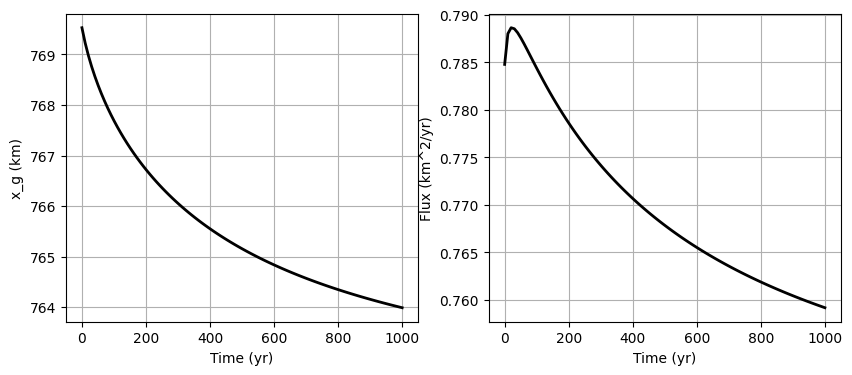

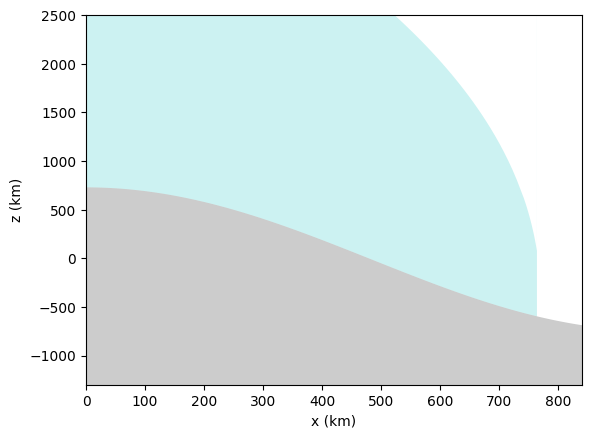

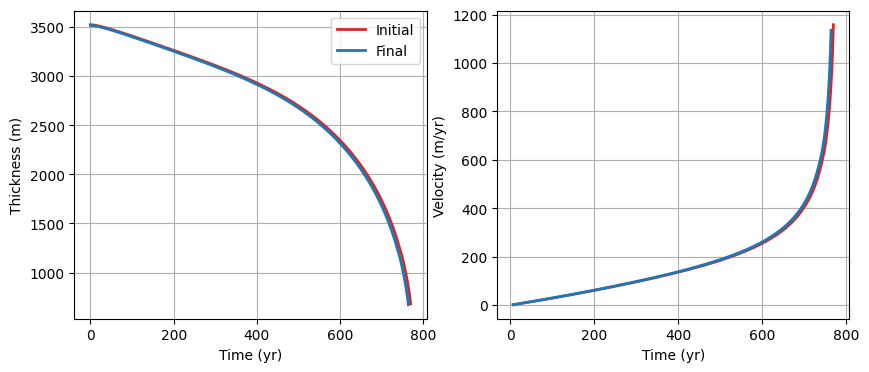

In [37]:
params['Nyears'] = 1000 # length of transient simulation in years
params['tfinal'] = params['Nyears'] * params['year'] # length of transient simulation in seconds
params['dt'] = 10 * params['year'] # time step length
params['transient'] = 1
params['facemelt'] = 5 / params['year']

xgs, hs, us = flowline_run(huxg_init, params, grid, bed, flowline)

plot_transient_solution(xgs, hs, us, grid, params)